# Stochastic volatility

Stochastic-volatility models let the variance follow its *own* latent random process, rather than the deterministic recursion of GARCH. This is the Heston/SABR family used to price derivatives and to reproduce the slowly drifting turbulence of real returns.

::: {.callout-note}
## The model

$$dS = \mu S\, dt + \sqrt{V}\, S\, dW_1, \qquad dV = \kappa(\theta - V)\, dt + \sigma_v \sqrt{V}\, dW_2, \qquad \mathrm{Corr}(dW_1, dW_2) = \rho$$

The observed series is driven by a hidden volatility process that evolves stochastically over time; the two can be correlated (a leverage effect). Because volatility is latent and mean-reverting, bursts arrive and fade more smoothly than under GARCH.
:::

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import StochasticVolatilityGenerator

## 1. Heston model (1 year daily)

The Heston model features mean-reverting stochastic variance with a leverage effect
(negative correlation between price and volatility).

In [ ]:
params = {
    "min_length": 252,
    "max_length": 252,
    "freq": "D",
    "model": "heston",
    "initial_price": 100.0,
    "initial_vol": 0.04,
    "drift": 0.05,
    "mean_vol": 0.04,
    "vol_mean_reversion": 2.0,
    "vol_of_vol": 0.3,
    "correlation": -0.7,
    "seed": 42,
}

generator = StochasticVolatilityGenerator(engine="polars", **params)
df = generator.generate(n_series=3)

print(f"Generated {df['unique_id'].n_unique()} price paths")

stats = df.group_by("unique_id").agg(
    [
        pl.col("y").first().alias("start_price"),
        pl.col("y").last().alias("end_price"),
        pl.col("y").min().alias("min_price"),
        pl.col("y").max().alias("max_price"),
    ]
)
stats

Generated 3 price paths


unique_id,start_price,end_price,min_price,max_price
cat,f64,f64,f64,f64
"""2""",100.0,102.874148,76.299762,102.874148
"""0""",100.0,71.796065,64.666513,115.173901
"""1""",100.0,90.226888,82.753918,103.886735


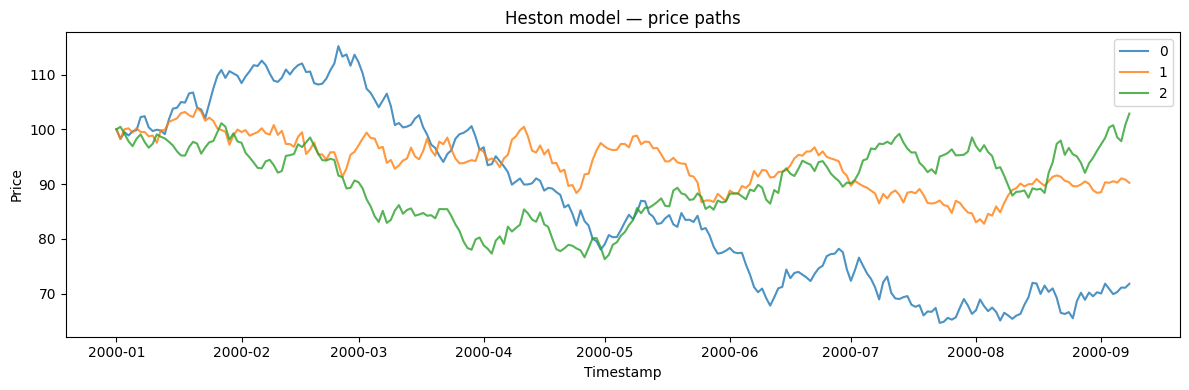

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df["unique_id"].unique().to_list():
    series = df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
ax.set_title("Heston model — price paths")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Price and volatility paths

Generate both the price and volatility paths to observe their joint dynamics.

In [ ]:
prices, vols, ids = generator.generate_with_volatility(n_series=1)
print(f"Price range: [{prices.min():.2f}, {prices.max():.2f}]")
print(f"Volatility range: [{vols.min():.3f}, {vols.max():.3f}]")
print(f"Mean volatility: {vols.mean():.3f} ({vols.mean() * np.sqrt(252) * 100:.1f}% annualized)")

Price range: [83.34, 109.86]
Volatility range: [0.155, 0.309]
Mean volatility: 0.227 (359.7% annualized)


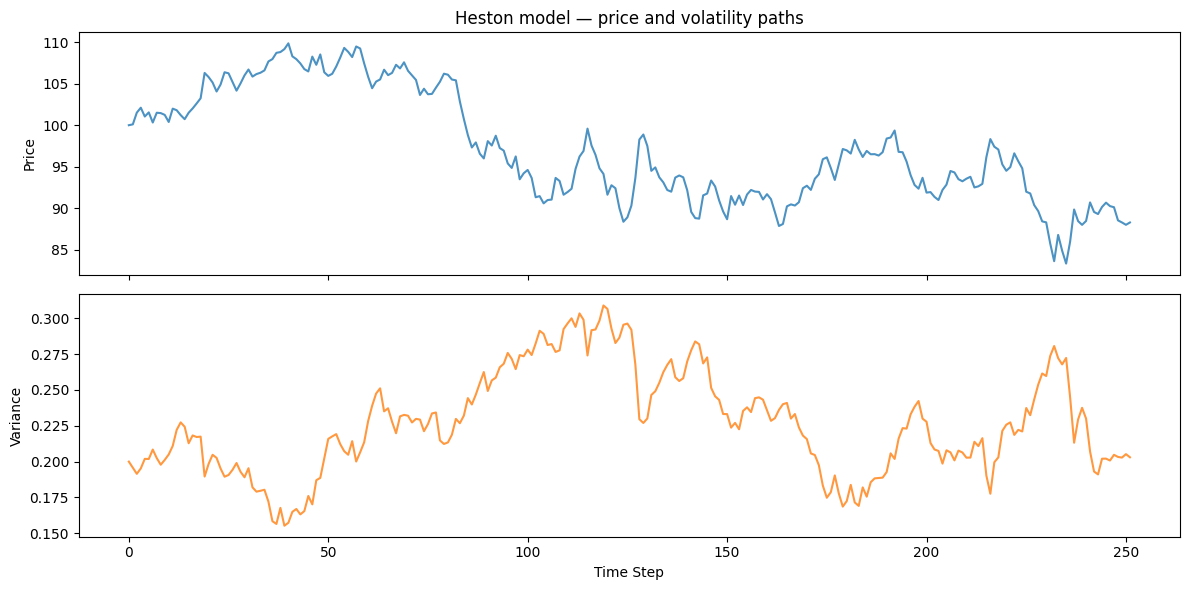

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(prices, alpha=0.8)
axes[0].set_ylabel("Price")
axes[0].set_title("Heston model — price and volatility paths")
axes[1].plot(vols, alpha=0.8, color="tab:orange")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Variance")
plt.tight_layout()
plt.show()

## 3. Leverage effect (price-vol correlation)

Verify that returns and volatility changes are negatively correlated (leverage effect).

In [ ]:
returns = np.diff(np.log(prices))
vol_changes = np.diff(vols)
corr = np.corrcoef(returns, vol_changes)[0, 1]
print(f"Return-VolChange correlation: {corr:.3f}")
print("(Negative = leverage effect: vol rises when prices fall)")

Return-VolChange correlation: -0.666
(Negative = leverage effect: vol rises when prices fall)


## 4. SABR model

The SABR (Stochastic Alpha Beta Rho) model is widely used for interest rate derivatives
and allows a CEV exponent (beta) to control the volatility smile shape.

In [ ]:
sabr_gen = StochasticVolatilityGenerator(engine="polars", 
    **{
        "min_length": 252,
        "max_length": 252,
        "freq": "D",
        "model": "sabr",
        "initial_price": 100.0,
        "beta": 0.5,
        "correlation": -0.3,
        "seed": 42,
    }
)
sabr_df = sabr_gen.generate(n_series=1)
print(f"SABR price range: [{sabr_df['y'].min():.2f}, {sabr_df['y'].max():.2f}]")

SABR price range: [95.99, 101.42]


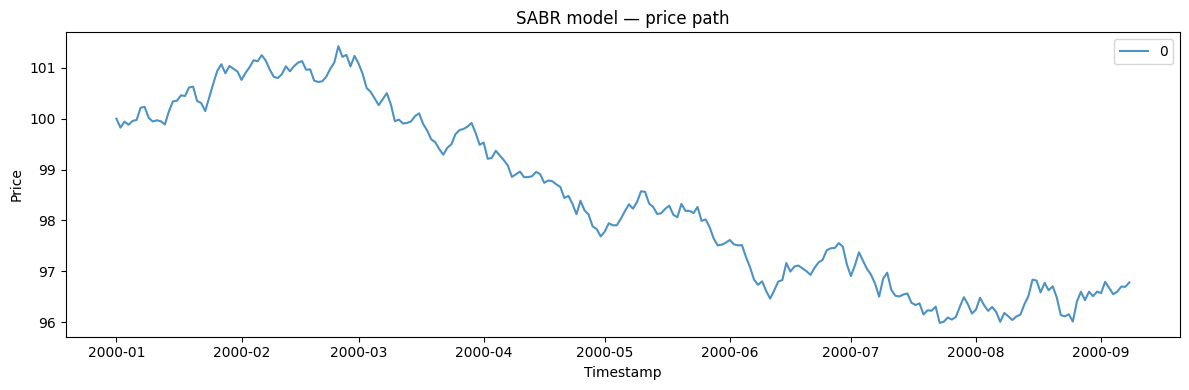

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in sabr_df["unique_id"].unique().to_list():
    series = sabr_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
ax.set_title("SABR model — price path")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Model information

Inspect the full model parameters.

In [ ]:
info = generator.get_model_info()
for key, value in info.items():
    print(f"{key}: {value}")

model: heston
initial_price: 100.0
initial_vol: 0.04
drift: 0.05
vol_of_vol: 0.3
correlation: -0.7
leverage_effect: True
dt: 0.003968253968253968
output_type: price
mean_vol: 0.04
vol_mean_reversion: 2.0
feller_condition_satisfied: True
feller_value: 0.07


## 6. Implied volatility smile (SABR)

Compute the implied volatility smile from the SABR model for various strike prices.

In [ ]:
strikes = np.array([80, 90, 95, 100, 105, 110, 120])
impl_vols = sabr_gen.implied_volatility_smile(strikes, maturity=1.0)

print("Strike | Implied Vol")
print("-" * 25)
for k, iv in zip(strikes, impl_vols):
    print(f"  {k:3d}  |   {iv * 100:.2f}%")

Strike | Implied Vol
-------------------------
   80  |   3.98%
   90  |   2.89%
   95  |   2.39%
  100  |   20.00%
  105  |   1.95%
  110  |   2.15%
  120  |   2.72%


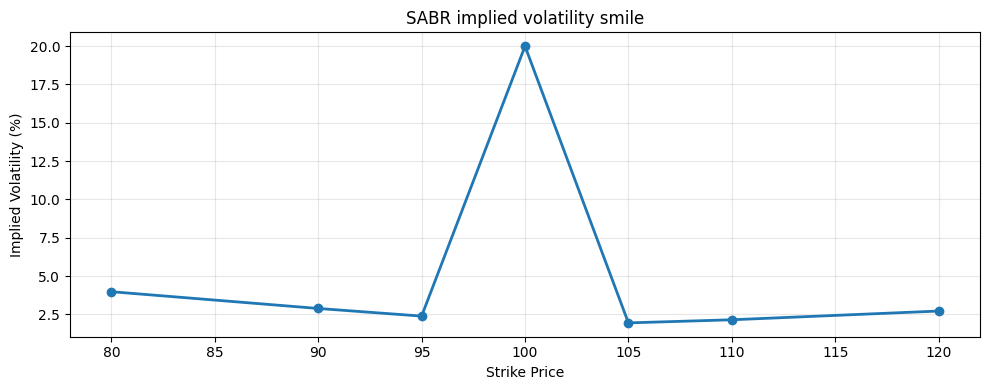

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(strikes, impl_vols * 100, marker="o", linewidth=2)
ax.set_xlabel("Strike Price")
ax.set_ylabel("Implied Volatility (%)")
ax.set_title("SABR implied volatility smile")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Output types

The generator supports different output types: price, returns, and volatility.

In [ ]:
for output_type in ["price", "returns", "volatility"]:
    gen = StochasticVolatilityGenerator(engine="polars", 
        **{
            "min_length": 100,
            "max_length": 100,
            "freq": "D",
            "output_type": output_type,
            "seed": 42,
        }
    )
    out_df = gen.generate(n_series=1)
    vals = out_df["y"].to_numpy()
    print(f"{output_type:12s}: mean={vals.mean():.4f}, std={vals.std():.4f}")

price       : mean=104.0363, std=6.2124
returns     : mean=-0.0010, std=0.0140
volatility  : mean=0.2009, std=0.0333


::: {.callout-tip}
## Related generators

- [GARCH](garch) — deterministic-recursion volatility clustering.
- [Ornstein-Uhlenbeck](ornstein_uhlenbeck) — the mean-reverting process often used for the latent variance.

Model parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::